# **Image Super Resolution — ESPCN**

**Updated for augmented dataset (149490 images)**



## **Cell 1 — Imports & Device**

In [ ]:
import os, random, math
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt

# setting up my main folders

PROJECT_ROOT = Path.home() / 'sr_project'
HR_DIR  = PROJECT_ROOT / 'HR_256'
LR_DIR  = PROJECT_ROOT / 'LR_x4'
OUT_DIR = PROJECT_ROOT / 'espcn_compare'
CKPT    = PROJECT_ROOT / 'best_espcn_x4.pth'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# just check if folder exist

assert HR_DIR.exists(), f'HR_256 not found at {HR_DIR}'
assert LR_DIR.exists(), f'LR_x4  not found at {LR_DIR}'

print('HR_DIR :', HR_DIR)
print('LR_DIR :', LR_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

HR_DIR : /home/rokib/sr_project/HR_256
LR_DIR : /home/rokib/sr_project/LR_x4

Device : cuda
GPU    : NVIDIA GeForce RTX 5060 Ti
VRAM   : 17.1 GB


## **Cell 2 — Auto-Detect Dataset Size & Build Train/Val/Test IDs**

This code now scan the HR folder and split **80/10/10** automatic.


In [ ]:
# ── Scan HR_256 and collect all image stems (the numeric IDs) ─────────────────
all_stems = sorted(
    p.stem for p in HR_DIR.iterdir()
    if p.suffix.lower() in ('.png', '.jpg', '.jpeg') and
       (LR_DIR / p.name).exists()   # only keep IDs that have a matching LR file
)

total = len(all_stems)
assert total >= 10, f'Too few images found: {total}. Check HR_256 and LR_x4 folders.'

# calculate 80 / 10 / 10 split
n_train = int(total * 0.80)
n_val   = int(total * 0.10)
n_test  = total - n_train - n_val

# random shuffle with seed 42 so it stay same every run
rng = random.Random(42)
shuffled = all_stems.copy()
rng.shuffle(shuffled)

train_ids = shuffled[:n_train]
val_ids   = shuffled[n_train:n_train + n_val]
test_ids  = shuffled[n_train + n_val:]

print(f'Total paired images : {total}')
print(f'Train               : {len(train_ids)}  ({len(train_ids)/total*100:.0f}%)')
print(f'Val                 : {len(val_ids)}   ({len(val_ids)/total*100:.0f}%)')
print(f'Test                : {len(test_ids)}   ({len(test_ids)/total*100:.0f}%)')

Total paired images : 149490
Train               : 119592  (80%)
Val                 : 14949   (10%)
Test                : 14949   (10%)


## **Cell 3 — Dataset Classes**

In [ ]:
def find_img(folder: Path, id_: str) -> Path:
    for ext in ['.png', '.jpg', '.jpeg']:
        p = folder / f'{id_}{ext}'
        if p.exists():
            return p
    raise FileNotFoundError(f'No image for id={id_} in {folder}')


class SRDataset(Dataset):
    """dataset for training. it load patches and apply some augmentation"""
    def __init__(self, lr_dir, hr_dir, ids, scale=4, patch_size=32, augment=True):
        self.lr_dir     = Path(lr_dir)
        self.hr_dir     = Path(hr_dir)
        self.ids        = ids
        self.scale      = scale
        self.patch_size = patch_size
        self.augment    = augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id_ = self.ids[idx]
        lr  = TF.to_tensor(Image.open(find_img(self.lr_dir, id_)).convert('RGB'))
        hr  = TF.to_tensor(Image.open(find_img(self.hr_dir, id_)).convert('RGB'))

        _, h, w = lr.shape
        p, s    = self.patch_size, self.scale

        # check if LR image is smaller than patch. if yes then skip the random crop
        if h <= p or w <= p:
            lr_patch = TF.resize(lr, [p, p])
            hr_patch = TF.resize(hr, [p*s, p*s])
        else:
            top  = random.randint(0, h - p)
            left = random.randint(0, w - p)
            lr_patch = lr[:, top:top+p,       left:left+p]
            hr_patch = hr[:, top*s:(top+p)*s, left*s:(left+p)*s]

        if self.augment:
            if random.random() < 0.5:
                lr_patch = TF.hflip(lr_patch); hr_patch = TF.hflip(hr_patch)
            if random.random() < 0.5:
                lr_patch = TF.vflip(lr_patch); hr_patch = TF.vflip(hr_patch)
            k = random.randint(0, 3)
            if k:
                lr_patch = torch.rot90(lr_patch, k, [1, 2])
                hr_patch = torch.rot90(hr_patch, k, [1, 2])

        return lr_patch, hr_patch


class SRImageDataset(Dataset):
    """Full-image dataset for validation / test."""
    def __init__(self, lr_dir, hr_dir, ids):
        self.lr_dir = Path(lr_dir)
        self.hr_dir = Path(hr_dir)
        self.ids    = ids

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id_ = self.ids[idx]
        lr  = TF.to_tensor(Image.open(find_img(self.lr_dir, id_)).convert('RGB'))
        hr  = TF.to_tensor(Image.open(find_img(self.hr_dir, id_)).convert('RGB'))
        return lr, hr, id_


print('Dataset classes defined.')

Dataset classes defined.


## **Cell 4 — DataLoaders**

In [4]:
SCALE = 4
PATCH = 32
BATCH = 16

train_ds     = SRDataset(LR_DIR, HR_DIR, train_ids, scale=SCALE, patch_size=PATCH, augment=True)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)

val_ds       = SRImageDataset(LR_DIR, HR_DIR, val_ids)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

test_ds      = SRImageDataset(LR_DIR, HR_DIR, test_ids)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

print(f'Train  samples  : {len(train_ds)}  →  {len(train_loader)} batches (batch_size={BATCH})')
print(f'Val    images   : {len(val_ds)}')
print(f'Test   images   : {len(test_ds)}')

Train  samples  : 119592  →  7475 batches (batch_size=16)
Val    images   : 14949
Test   images   : 14949


## **Cell 5 — ESPCN Model**

In [ ]:
class ESPCN(nn.Module):
    
    # my ESPCN model. it use sub-pixel convolution to upscale.
    # process in LR space so its faster.

    def __init__(self, scale=4):
        super().__init__()
        self.scale = scale
        self.net = nn.Sequential(
            nn.Conv2d(3,   64, 5, padding=2), nn.ReLU(True),
            nn.Conv2d(64, 64,  3, padding=1), nn.ReLU(True),
            nn.Conv2d(64, 32,  3, padding=1), nn.ReLU(True),
            nn.Conv2d(32, 3 * (scale ** 2), 3, padding=1)   # 3×16=48 channels
        )
        # Sub-pixel shuffle: (B, 48, H, W) → (B, 3, H*4, W*4)
        self.pixel_shuffle = nn.PixelShuffle(scale)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return torch.clamp(self.pixel_shuffle(self.net(x)), 0, 1)


model  = ESPCN(scale=SCALE).to(device)
params = sum(p.numel() for p in model.parameters())
print(f'ESPCN ready — {params:,} parameters on {device}')

ESPCN ready — 74,128 parameters on cuda


## **Cell 6 — Helper Functions**

In [ ]:
def psnr(sr, hr):
    mse = F.mse_loss(sr.clamp(0,1), hr.clamp(0,1))
    return 10 * torch.log10(1.0 / (mse + 1e-8))

def t2pil(x):
    return TF.to_pil_image(x.squeeze(0).cpu().clamp(0, 1))

def bicubic_up(x, scale=4):
    # bicubic function just to compare the result later
    return F.interpolate(x, scale_factor=scale,
                         mode='bicubic', align_corners=False).clamp(0, 1)

def validate_psnr(loader):
    model.eval()
    vals = []
    with torch.no_grad():
        for lr_img, hr_img, _ in loader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)
            sr = model(lr_img)          # ← ESPCN takes LR directly, no bicubic needed
            vals.append(psnr(sr, hr_img).item())
    return float(np.mean(vals))

print('Helper functions defined.')

Helper functions defined.


## **Cell 7 — Training Loop**

In [ ]:
import time

EPOCHS    = 100
criterion = nn.L1Loss()           # L1 loss usually give sharper image than MSE
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
scaler    = torch.amp.GradScaler('cuda')

best_val = -1.0
history  = {'loss': [], 'val_psnr': []}

print('Starting ESPCN training...')
print(f'Epochs: {EPOCHS}  |  Batch: {BATCH}  |  Loss: L1  |  Scale: ×{SCALE}')
print(f'Train samples: {len(train_ds)}  |  Val images: {len(val_ds)}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    losses = []

    for lr_patch, hr_patch in train_loader:
        lr_patch = lr_patch.to(device, non_blocking=True)
        hr_patch = hr_patch.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            sr   = model(lr_patch)        # ← feed LR directly (no bicubic)
            loss = criterion(sr, hr_patch)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())

    scheduler.step()
    val_ps   = validate_psnr(val_loader)
    avg_loss = float(np.mean(losses))
    elapsed  = time.time() - t0

    history['loss'].append(avg_loss)
    history['val_psnr'].append(val_ps)

    tag = ''
    if val_ps > best_val:
        best_val = val_ps
        torch.save(model.state_dict(), CKPT)
        tag = '  ✅ best saved'

    remaining = elapsed * (EPOCHS - epoch)
    print(f'Epoch {epoch:03d}/{EPOCHS} | Loss: {avg_loss:.6f} | '
          f'Val PSNR: {val_ps:.2f} dB | '
          f'{elapsed:.0f}s/ep | ETA: {remaining/3600:.1f}h{tag}')

print(f'\n✅ Training complete. Best Val PSNR: {best_val:.2f} dB')
print(f'Checkpoint → {CKPT}')

Starting ESPCN training...
Epochs: 100  |  Batch: 16  |  Loss: L1  |  Scale: ×4
Train samples: 119592  |  Val images: 14949
-----------------------------------------------------------------
Epoch 001/100 | Loss: 0.026078 | Val PSNR: 33.07 dB | 102s/ep | ETA: 2.8h  ✅ best saved
Epoch 002/100 | Loss: 0.018583 | Val PSNR: 33.20 dB | 100s/ep | ETA: 2.7h  ✅ best saved
Epoch 003/100 | Loss: 0.016925 | Val PSNR: 34.04 dB | 99s/ep | ETA: 2.7h  ✅ best saved
Epoch 004/100 | Loss: 0.015883 | Val PSNR: 33.51 dB | 96s/ep | ETA: 2.6h
Epoch 005/100 | Loss: 0.015253 | Val PSNR: 35.23 dB | 96s/ep | ETA: 2.5h  ✅ best saved
Epoch 006/100 | Loss: 0.014871 | Val PSNR: 35.07 dB | 96s/ep | ETA: 2.5h
Epoch 007/100 | Loss: 0.014620 | Val PSNR: 35.69 dB | 95s/ep | ETA: 2.4h  ✅ best saved
Epoch 008/100 | Loss: 0.014065 | Val PSNR: 34.04 dB | 94s/ep | ETA: 2.4h
Epoch 009/100 | Loss: 0.014176 | Val PSNR: 35.69 dB | 94s/ep | ETA: 2.4h  ✅ best saved
Epoch 010/100 | Loss: 0.013790 | Val PSNR: 36.04 dB | 93s/ep | ETA:

## **Cell 8 — Training History Plot**

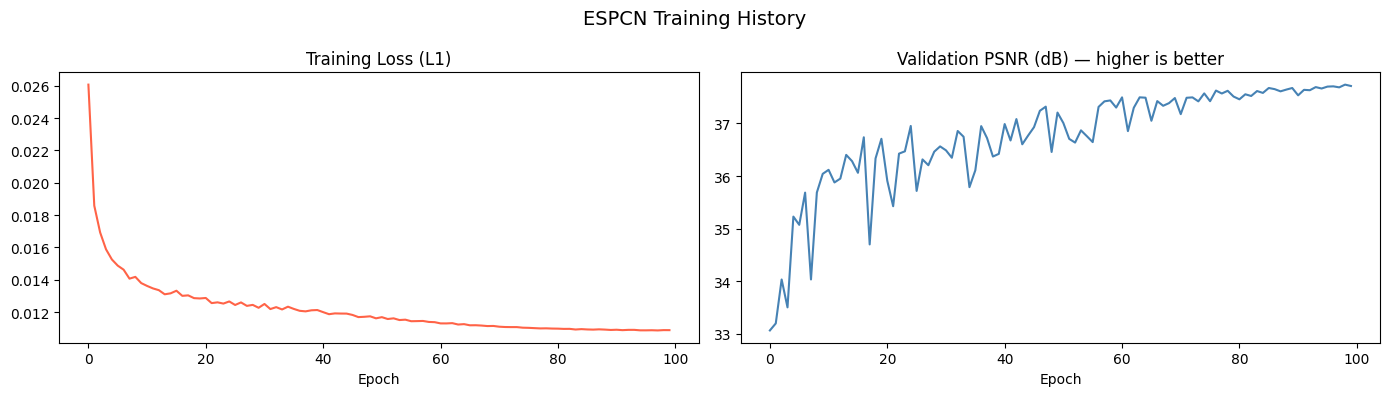

Saved → /home/rokib/sr_project/training_history.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['loss'], color='tomato')
ax1.set_title('Training Loss (L1)'); ax1.set_xlabel('Epoch')

ax2.plot(history['val_psnr'], color='steelblue')
ax2.set_title('Validation PSNR (dB) — higher is better'); ax2.set_xlabel('Epoch')


plt.suptitle('ESPCN Training History', fontsize=14)
plt.tight_layout()
save_path = PROJECT_ROOT / 'training_history.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Saved → {save_path}')

## **Run on Image**

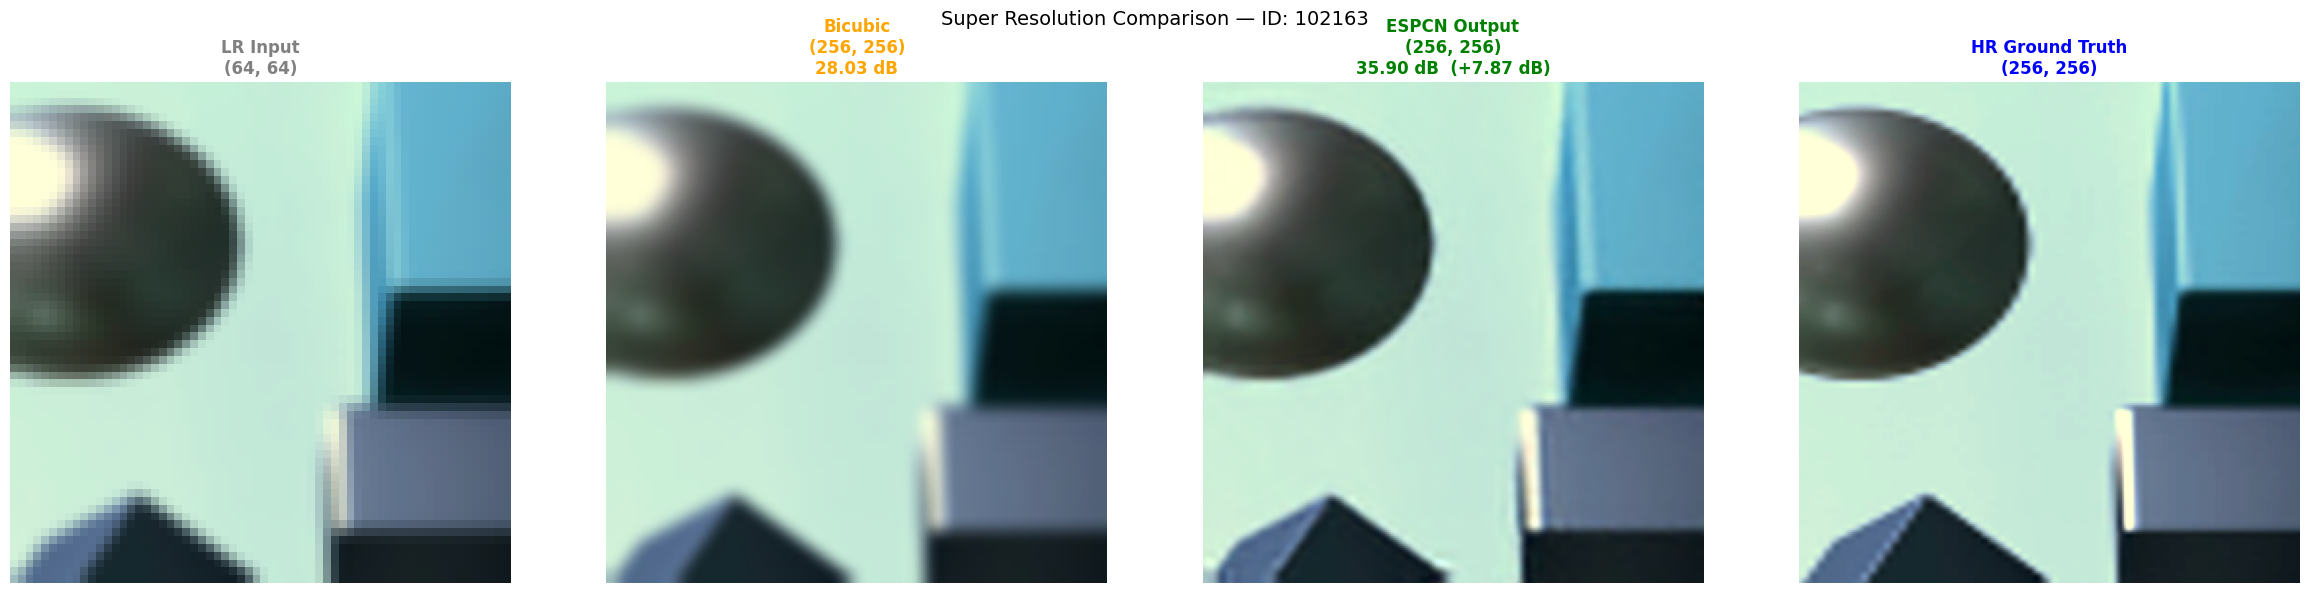

Bicubic PSNR : 28.03 dB
ESPCN   PSNR : 35.90 dB  (+7.87 dB gain)


In [ ]:
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image

# Pick a random image from test set 
sample_id = random.choice(test_ids)   # guaranteed to exist
lr_path   = find_img(LR_DIR, sample_id)
hr_path   = find_img(HR_DIR, sample_id)

lr_img = Image.open(lr_path).convert('RGB')
hr_img = Image.open(hr_path).convert('RGB')

# Run ESPCN 
model.load_state_dict(torch.load(CKPT, map_location=device, weights_only=True))
model.eval()

lr_tensor = TF.to_tensor(lr_img).unsqueeze(0).to(device)

with torch.no_grad():
    sr_tensor = model(lr_tensor).clamp(0, 1)

sr_img  = TF.to_pil_image(sr_tensor.squeeze(0).cpu())
bic_img = lr_img.resize(hr_img.size, Image.BICUBIC)

# PSNR scores 
hr_t  = TF.to_tensor(hr_img).unsqueeze(0).to(device)
bic_t = TF.to_tensor(bic_img).unsqueeze(0).to(device)

bic_psnr = psnr(bic_t,     hr_t).item()
sr_psnr  = psnr(sr_tensor, hr_t).item()

# Show LR → Bicubic → ESPCN → HR 
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

data = [
    (lr_img,  f'LR Input\n{lr_img.size}',                                          'gray'),
    (bic_img, f'Bicubic\n{bic_img.size}\n{bic_psnr:.2f} dB',                       'orange'),
    (sr_img,  f'ESPCN Output\n{sr_img.size}\n{sr_psnr:.2f} dB  ({sr_psnr - bic_psnr:+.2f} dB)', 'green'),
    (hr_img,  f'HR Ground Truth\n{hr_img.size}',                                    'blue'),
]

for ax, (img, title, color) in zip(axes, data):
    ax.imshow(img)
    ax.set_title(title, fontsize=12, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Super Resolution Comparison — ID: {sample_id}', fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / f'{sample_id}_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Bicubic PSNR : {bic_psnr:.2f} dB")
print(f"ESPCN   PSNR : {sr_psnr:.2f} dB  ({sr_psnr - bic_psnr:+.2f} dB gain)")